# 6주차 과제 2 보충: 이미지 추가 전후의 비용 비교

- 작성일: 2026-10-07.
- 대상: [6주차 과제 2 따라 하기 체크리스트](https://deepnlp-2026.halla.ai/weeks/week-06/).
- 기존 `week-06.ipynb`에 추가된 비교 기록. 2026-09-30 실행 결과와 분석은 기존 파일에 보존.
- 보충 항목: 같은 SmolVLM의 질문만/사진+질문 분할 끔/사진+질문 분할 켬 비교, 시각 토큰의 전체 문맥 점유율, 이미지 추가 전후 첫 토큰 지연 차이.
- 아래 세 조건의 숫자는 모두 2026-10-07 이 노트북에서 새로 측정. 9월 30일의 다른 질문 및 런타임 측정치와 혼합하지 않음.

## 1. 상정 조건과 재현 환경

- 제주 해양 환경 관측 기록을 정리하는 가상 소규모 조직. CPU 서버 1대, 실행 스레드 4개, 전용 GPU 사용 없음. 사진 1장당 첫 응답 5초 이내 목표.
- 기존 시나리오의 조건 유지: 월 2,000건, 사진 1장씩 연결. 월 운영 예산 50,000원 중 계산 자원 20,000원과 검토 보조 업무 30,000원. 계산 자원 시간당 1,000원의 가정 단가. 실제 계약, 지출, 기업 데이터 없음.
- 관측 지점 사진의 대체 자료로 기존 제출물과 동일한 우도 공개 사진 사용. 사진에서 보이는 내용의 초안이 용도이며 수질이나 오염 여부의 자동 판정은 범위 밖.
- 고정 질문: `Describe this image in one sentence.`
- SmolVLM 모델 revision 고정, CPU float32, seed 42, 탐욕 디코딩. 이미 설치된 패키지는 유지하고 없는 필수 패키지만 아래 셀에서 설치.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import sys
import json
import platform
import importlib.metadata as metadata
from datetime import datetime
from pathlib import Path
from time import perf_counter
import statistics
import subprocess
required = {
    "torch": "torch==2.8.0", "torchvision": "torchvision==0.23.0",
    "transformers": "transformers==4.57.6", "Pillow": "Pillow",
}
missing = []
for package, requirement in required.items():
    try:
        metadata.version(package)
    except metadata.PackageNotFoundError:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import torch
from PIL import Image
from IPython.display import display, Markdown

torch.set_num_threads(4)
torch.manual_seed(42)
print("실행 시각:", datetime.now().astimezone().isoformat(timespec="seconds"))
print("Python:", platform.python_version(), "OS:", platform.system(), platform.release())
print("실험 장치: CPU, dtype: float32, seed: 42, 스레드:", torch.get_num_threads())
for package in ["torch", "torchvision", "transformers", "Pillow"]:
    print(package, metadata.version(package))

실행 시각: 2026-10-07T16:57:07+09:00
Python: 3.10.0 OS: Windows 10
실험 장치: CPU, dtype: float32, seed: 42, 스레드: 4
torch 2.8.0+cpu
torchvision 0.23.0+cpu
transformers 4.57.6
Pillow 12.3.0


## 2. 공개 사진과 출처

| 항목 | 기록 |
|---|---|
| 제목 | Udo, Jeju Province, South Korea 02 |
| 저자 | 제주영상문화산업진흥원 |
| 출처 주소 | https://commons.wikimedia.org/wiki/File:Udo,_Jeju_Province,_South_Korea_02.jpg |
| 라이선스 | 공공누리 제1유형, KOGL Type 1 |
| 사용 범위 | 원본의 960px 썸네일. 별도 편집 없이 사용하고 모델 내부에서 분할/크기 조정 |

- 기존 제출물에서 확인한 사진과 같은 다운로드 주소 사용. 본 사진에서 식별 가능한 얼굴이나 개인정보를 분석하지 않음.

사진: udo.jpg 크기: (960, 539)
SHA256: b8482ba8f498f7ea431c7766ef24ca14d2f1860fe1b16997373bec86c96b8695


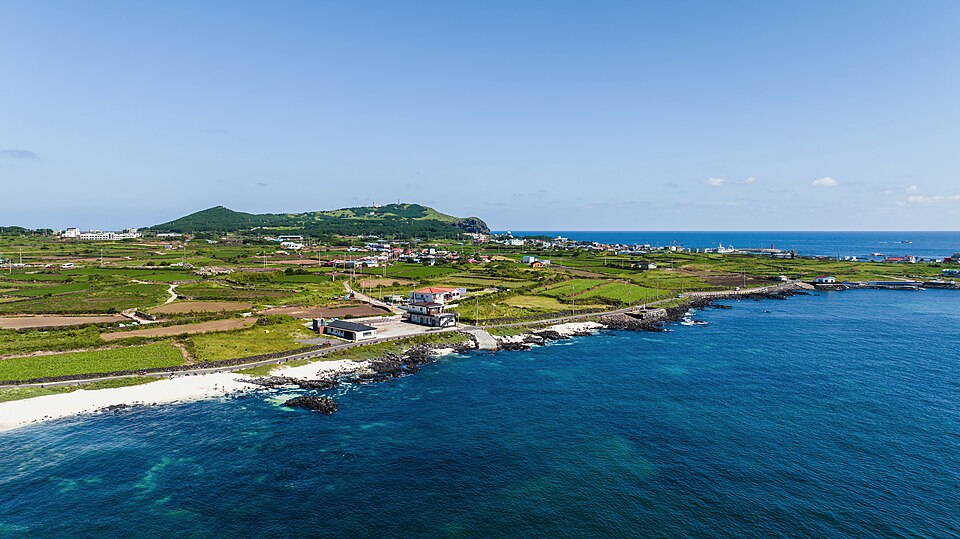

In [2]:
import hashlib
import urllib.request
import urllib.error
import time

IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Udo%2C_Jeju_Province%2C_South_Korea_02.jpg/960px-Udo%2C_Jeju_Province%2C_South_Korea_02.jpg"
image_path = Path("week06-imgs/udo.jpg")
image_path.parent.mkdir(exist_ok=True)
if not image_path.exists():
    for attempt in range(4):
        request = urllib.request.Request(IMAGE_URL, headers={
            "User-Agent": "deepnlp-2026/1.0 (https://github.com/halla-ai/deepnlp-2026)"
        })
        try:
            with urllib.request.urlopen(request, timeout=60) as response:
                image_path.write_bytes(response.read())
            break
        except urllib.error.HTTPError as exc:
            if exc.code != 429 or attempt == 3:
                raise
            time.sleep(15 * (attempt + 1))

observation_image = Image.open(image_path).convert("RGB")
print("사진:", image_path.name, "크기:", observation_image.size)
print("SHA256:", hashlib.sha256(image_path.read_bytes()).hexdigest())
display(observation_image)

## 3. 같은 모델에서 세 조건 측정

- 첫 토큰 시간: 입력 텐서가 준비된 뒤 `generate(max_new_tokens=1)` 호출부터 반환까지의 시간. 비전 인코더와 언어모형 처리는 포함, 이미지 다운로드/파일 읽기/전처리/모델 로딩/네트워크 전송/화면 표시는 제외.
- 세 조건 각각 사전 실행 1회 후 연속 3회 측정. 중앙값 및 최솟값-최댓값 기록. 모델과 질문을 고정하므로 사진이 없는 기준도 다른 텍스트 모델이 아닌 동일 SmolVLM 사용.
- 분할 설정은 4.57.6에서 호출 인자가 무시되는 문제를 피하도록 `image_processor.do_image_splitting` 속성을 임시 변경하고 복원. 기존 제출물과 같은 보완 방식.
- 시각 토큰 / 모델 최대 문맥 8192를 직접 계산. 입력 전체 대비 시각 토큰 비중과 혼동하지 않음.
- 전처리 시간은 별도로 1회 측정. 세 조건은 질문만, 분할 끔, 분할 켬 순서로 실행하므로 장시간 운영이나 동시 요청의 지연 분포를 대표하지 않음.

In [3]:
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL = "HuggingFaceTB/SmolVLM-256M-Instruct"
REVISION = "7e3e67edbbed1bf9888184d9df282b700a323964"
QUESTION = "Describe this image in one sentence."
processor = AutoProcessor.from_pretrained(MODEL, revision=REVISION, use_fast=False)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL, revision=REVISION, dtype=torch.float32
).to("cpu").eval()
processor.image_processor.do_image_splitting = False
context_limit = model.config.text_config.max_position_embeddings
assert context_limit == 8192
assert next(model.parameters()).device.type == "cpu"
assert next(model.parameters()).dtype == torch.float32
print("모델:", MODEL)
print("revision:", model.config._commit_hash)
print("문맥 창:", context_limit)

def build_inputs(image=None, split=False):
    content = [] if image is None else [{"type": "image"}]
    content.append({"type": "text", "text": QUESTION})
    prompt = processor.apply_chat_template(
        [{"role": "user", "content": content}], add_generation_prompt=True
    )
    if image is None:
        return processor(text=prompt, return_tensors="pt")
    previous = processor.image_processor.do_image_splitting
    processor.image_processor.do_image_splitting = split
    try:
        return processor(images=image, text=prompt, return_tensors="pt")
    finally:
        processor.image_processor.do_image_splitting = previous

conditions = [
    ("질문만 (사진 없음)", None, False),
    ("사진 + 질문 (분할 끔)", observation_image, False),
    ("사진 + 질문 (분할 켬)", observation_image, True),
]
measurements = []
for label, image_input, split in conditions:
    start = perf_counter()
    inputs = build_inputs(image_input, split)
    preprocess_s = perf_counter() - start
    ids = inputs["input_ids"][0]
    visual = int((ids == processor.image_token_id).sum())
    with torch.inference_mode():
        model.generate(**inputs, max_new_tokens=1, do_sample=False)
    samples = []
    for repeat in range(3):
        start = perf_counter()
        with torch.inference_mode():
            model.generate(**inputs, max_new_tokens=1, do_sample=False)
        samples.append(perf_counter() - start)
    row = {
        "condition": label, "input_tokens": len(ids), "visual_tokens": visual,
        "visual_context_percent": 100 * visual / context_limit,
        "ttft_samples_s": samples, "ttft_median_s": statistics.median(samples),
        "preprocess_s": preprocess_s,
    }
    measurements.append(row)
    print(label, json.dumps(row, ensure_ascii=False))

assert [row["visual_tokens"] for row in measurements] == [0, 64, 832]
assert not processor.image_processor.do_image_splitting
print("세 조건 시각 토큰 및 분할 설정 복원 검증 통과")

C:\Users\User\Desktop\School2\tmp\deepnlp_20261007\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


모델: HuggingFaceTB/SmolVLM-256M-Instruct
revision: 7e3e67edbbed1bf9888184d9df282b700a323964
문맥 창: 8192


질문만 (사진 없음) {"condition": "질문만 (사진 없음)", "input_tokens": 15, "visual_tokens": 0, "visual_context_percent": 0.0, "ttft_samples_s": [0.05530410003848374, 0.0532816001214087, 0.051364799961447716], "ttft_median_s": 0.0532816001214087, "preprocess_s": 0.006170700071379542}


사진 + 질문 (분할 끔) {"condition": "사진 + 질문 (분할 끔)", "input_tokens": 82, "visual_tokens": 64, "visual_context_percent": 0.78125, "ttft_samples_s": [1.7502470999024808, 1.0320340998005122, 1.0408068001270294], "ttft_median_s": 1.0408068001270294, "preprocess_s": 0.07587899989448488}


사진 + 질문 (분할 켬) {"condition": "사진 + 질문 (분할 켬)", "input_tokens": 877, "visual_tokens": 832, "visual_context_percent": 10.15625, "ttft_samples_s": [14.703233500011265, 12.68424279987812, 12.468980400124565], "ttft_median_s": 12.68424279987812, "preprocess_s": 0.2645900999195874}
세 조건 시각 토큰 및 분할 설정 복원 검증 통과


In [4]:
summary = "| 입력 | 입력 토큰 | 시각 토큰 | 문맥 창 대비 시각 토큰 | 첫 토큰까지 중앙값 | 3회 범위 |\n|---|---:|---:|---:|---:|---:|\n"
baseline = measurements[0]
for row in measurements:
    samples = row["ttft_samples_s"]
    summary += (f"| {row['condition']} | {row['input_tokens']} | {row['visual_tokens']} | "
                f"{row['visual_context_percent']:.2f}% | {row['ttft_median_s']:.3f} s | "
                f"{min(samples):.3f}-{max(samples):.3f} s |\n")
display(Markdown(summary))
for row in measurements[1:]:
    print(f"{row['condition']}: 질문만 대비 입력 +{row['input_tokens']-baseline['input_tokens']}토큰, "
          f"모델 첫 토큰 +{row['ttft_median_s']-baseline['ttft_median_s']:.3f}초 "
          f"({row['ttft_median_s']/baseline['ttft_median_s']:.2f}배), "
          f"별도 전처리 {row['preprocess_s']:.3f}초")
print("METRICS_JSON")
print(json.dumps({"question": QUESTION, "context_limit": context_limit,
                  "model_revision": REVISION, "measurements": measurements},
                 ensure_ascii=False, indent=2))

| 입력 | 입력 토큰 | 시각 토큰 | 문맥 창 대비 시각 토큰 | 첫 토큰까지 중앙값 | 3회 범위 |
|---|---:|---:|---:|---:|---:|
| 질문만 (사진 없음) | 15 | 0 | 0.00% | 0.053 s | 0.051-0.055 s |
| 사진 + 질문 (분할 끔) | 82 | 64 | 0.78% | 1.041 s | 1.032-1.750 s |
| 사진 + 질문 (분할 켬) | 877 | 832 | 10.16% | 12.684 s | 12.469-14.703 s |


사진 + 질문 (분할 끔): 질문만 대비 입력 +67토큰, 모델 첫 토큰 +0.988초 (19.53배), 별도 전처리 0.076초
사진 + 질문 (분할 켬): 질문만 대비 입력 +862토큰, 모델 첫 토큰 +12.631초 (238.06배), 별도 전처리 0.265초
METRICS_JSON
{
  "question": "Describe this image in one sentence.",
  "context_limit": 8192,
  "model_revision": "7e3e67edbbed1bf9888184d9df282b700a323964",
  "measurements": [
    {
      "condition": "질문만 (사진 없음)",
      "input_tokens": 15,
      "visual_tokens": 0,
      "visual_context_percent": 0.0,
      "ttft_samples_s": [
        0.05530410003848374,
        0.0532816001214087,
        0.051364799961447716
      ],
      "ttft_median_s": 0.0532816001214087,
      "preprocess_s": 0.006170700071379542
    },
    {
      "condition": "사진 + 질문 (분할 끔)",
      "input_tokens": 82,
      "visual_tokens": 64,
      "visual_context_percent": 0.78125,
      "ttft_samples_s": [
        1.7502470999024808,
        1.0320340998005122,
        1.0408068001270294
      ],
      "ttft_median_s": 1.0408068001270294,
      "preprocess_s": 0.07587899

## 4. 관찰 - 근거 - 해석 - 다음

| 구분 | 기록 |
|---|---|
| 관찰 | 질문만: 입력 15토큰, 시각 0토큰, 첫 토큰 중앙값 0.053초. 사진 추가/분할 끔: 입력 82토큰, 시각 64토큰, 1.041초. 분할 켬: 입력 877토큰, 시각 832토큰, 12.684초 |
| 근거 | 2026-10-07 실행 출력. 동일 SmolVLM revision, 동일 영어 질문, 동일 우도 사진, CPU float32/4스레드/seed 42, 조건별 1회 사전 실행과 3회 시간 측정. 각 개별 시간은 위 JSON에 보존 |
| 해석 | 사진 추가/분할 끔은 질문만 대비 입력 +67토큰, 모델 첫 토큰 +0.988초. 분할 켬은 +862토큰, +12.631초. 비전 인코더와 더 긴 언어 문맥 처리의 비용이 함께 증가 |
| 다음 | 5초 첫 응답 목표에 대해 모델 첫 토큰 중앙값은 분할 끔 이내, 분할 켬 초과. 기본 후보는 분할 끔으로 설정하고, 필요한 사진만 사람이 추가 확인. 실제 운영 결정 전 파일 읽기/전처리/대기열/전송/표시를 포함한 첫 응답 시간과 관측 내용의 정확성을 추가 검증 |

□ 문맥 창 대비 시각 토큰

- 질문만: 0/8192 = 0%.
- 사진+질문, 분할 끔: 64/8192 = 0.78%.
- 사진+질문, 분할 켬: 832/8192 = 10.16%.
- 이 비율은 시각 토큰을 전체 문맥 창 8192로 나눈 값. 시각 토큰/현재 입력 토큰, 전체 입력 토큰/문맥 창과 다른 지표.
- 분할 켬에서 사진 9장의 시각 토큰만 832 x 9 = 7488개, 문맥의 91.41%. 10장은 8320개로 문맥 창 초과. 템플릿, 질문, 이전 기록, 생성 답변 토큰을 더하면 사용 가능한 사진 수는 더 작아짐.
- 분할 끔도 사진 128장만으로 64 x 128 = 8192개이므로 실제로 128장을 담을 수 있다는 뜻이 아님. 다중 사진 추론을 실행한 결과가 아니라 1장 실측값에서 계산한 용량 한계.

□ 선택의 근거와 한계

- 분할 켬의 시각 토큰은 끔의 13배. 모델 첫 토큰 중앙값은 12.19배. 비용이 토큰 수에 정확히 비례한다고 가정하지 않고 두 수치를 별도로 관찰.
- 이번 보충 측정은 첫 토큰 지연의 비교. 48토큰 전체 답변 생성시간, 동시 요청의 대기시간, 유휴 서버 시간, 사람 검토 시간은 새로 측정하지 않았으므로 월 계산비나 총 운영비를 이 값에서 확정할 수 없음.
- 9월 30일 제출물의 1.007초/11.999초는 `Describe the visible coastline and water. Do not guess the location or water quality.`라는 다른 질문과 당시 환경의 결과. 이번 표에 참고값으로 섞지 않으며 두 날짜의 차이를 속도 개선이나 회귀로 해석하지 않음.
- 세 조건 모두 같은 모델이므로 모델 종류의 차이는 제거했지만 질문만/분할 끔/분할 켬 순서와 시스템의 다른 부하 영향은 완전히 통제하지 못함. 3회 범위로 운영 지연의 꼬리 분포나 5초 서비스 보장을 판정할 수 없음.
- 정확도와 환각 사례, 사진 비율별 토큰 수, 전체 생성 기반의 가정 비용은 기존 `week-06.ipynb`에 기록. 이번 보충은 누락된 사진 없는 기준값과 직접적인 시각/문맥 비율을 추가한 것으로, 기존 출력과 분석을 대체하지 않음.
